1. Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

2. Set Data Path (Google Drive or Local)

In [2]:
# Mount Google Drive if running on Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    # Use Google Drive for data storage
    DATA_PATH = '/content/drive/MyDrive/data'
    print("Google Drive mounted. Data path set to:", DATA_PATH)
except (ImportError, ValueError, Exception) as e:
    # Use local directory if not on Colab OR if drive mount fails
    DATA_PATH = './data'
    print("Drive mount failed or not running on standard Colab.")
    print(f"Error: {e}")
    print("Data path set to:", DATA_PATH)
    print("Note: If using VS Code with Colab, enable 'Colab: Mount Drive' in settings to support drive.mount().")

Mounted at /content/drive
Google Drive mounted. Data path set to: /content/drive/MyDrive/data


Set Hardware Device

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Set Hyperparameter

In [4]:
# Hyperparameters
BATCH_SIZE = 128
EPOCHS = 30
LEARNING_RATE = 3e-4
PATCH_SIZE = 4
NUM_CLASSES = 10
IMAGE_SIZE = 32
CHANNELS = 3
EMBED_DIM = 256
NUM_HEADS = 8
DEPTH = 6
MLP_DIM = 512
DROP_RATE = 0.1

Data Preprocessing

In [5]:
# 5.1 Set mean and std of CIFAR10
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
# Thoes number was calculate by community

# 5.2 Preprocessing Training Data
train_transform = transforms.Compose([
    # 5.2.1 Crop
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    # First, it adds a border of 4 pixels (padding=4) around the original 32x32 image
    # It mirrors the image at the edges (padding_mode = 'reflect')
    # Then it randomly cuts out a 32x32 square from that larger 40x40 image
    # --> We get a 32x32 image that is slightly shifted --> that forces the model
    # to learn that a dog is still a dog even if it's not perfectly centered
    # --> Translation Invariance

    # 5.2.2 Flip horizontally the Image randomly
    transforms.RandomHorizontalFlip(),

    # 5.2.3 Convert the image from PIL Image / Nummy Array into a PyTorch Tensor
    transforms.ToTensor(),
    # (H, W, C) -> (C, H, W)

    # 5.2.3 Normalization on the tensor
    transforms.Normalize(*stats, inplace=True)
    # *stats: unpacks the stats tuple
    # inplace=True: Modifies the tensor directly in memory to save RAM
    # --> The pixel Values will be centered around 0 and have a variance of 1
    # --> helps train faster and stably 
])

# 5.2 Preprocessing Test Data
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

Download Dataset, if not

In [6]:
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

100%|██████████| 170M/170M [00:02<00:00, 70.6MB/s] 


Load Dataset

In [7]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### ViT components

1. Embedding Patches

In [8]:
class PatchEmbedding(nn.Module):
    # 1.1:
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        # 1.1.1:
        super().__init__()

        # 1.1.2:
        self.patch_size = patch_size

        # 1.1.3: Create a Convolutional Layer
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        # nn.Conv2d returns the Convolutional Layer Object itself.
        # embed_dim: This is the dimension into which each patch is projected (Hidden Size D)
        # kernel_size: The size of patches (PxP)
        # stride: Step Size of the filter (The filter moves patch_size after each calculation)
        # kernel_size = stride -> No overlap
        # -> This perfectly slides the image into a gird of non-overlapping patches

        # 1.1.4: Calculate the number of patches
        num_patches = (img_size // patch_size) ** 2

        # 1.1.5: Initialize learnable class token (1, 1, D) and positional Embedding (1, N+1, D)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, 1 + num_patches, embed_dim))

    # 1.2. 
    def forward(self, x):
        # 1.2.1: Extract the Batch Size
        B = x.size(0)

        # 1.2.2: 
        x = self.proj(x)  # (B, D, H/P, W/P)
        # proj is an object designed to be callable
        # proj(x): Python automatically calls the layer's forward methode behind the scenes
        # The layer takes x, performs the convolution math using its internal weights and
        # returns the result.
        # For each path in the image, we get back a vector of size embed_dim
        # -> We'll get a whole gird of vectors for an image
        # x is a Batch with B images, proj knows that and executes on each images of the batch

        # 1.2.3:
        x = x.flatten(2).transpose(1, 2)  #  -> (B, D, H/P, W/P) -> (B, D, N) -> (B, N, D)

        # flatten(2): The argument 2 tells Pytorch to start flattening from dimension
        # index 2 and merge all subsequent dimension into one. (B, D, H_p, W_p) -> (B, D, N)
        # N = H_p * W_p: represents the total number of patches (or tokens)

        # transpose(1, 2): swaps the dimensions from (B, D, N) to (B, N, D) because Pytorch's 
        # nn.MultiheadAttention (by default batch_first=True) expects the input in the format:
        # (Batch, Sequence Length, Feature Dimension (Embedding))

        # 1.2.4:
        cls_tokens = self.cls_token.expand(B, -1, -1)
        # cls_token is a learnable parameter initialized with shape (1, 1, D). It is the same
        # for every image. We couldnt initialize cls_token as (B, 1, D) because the Batch Size
        # B will change:
        # - During training (32)
        # - During validation (64)
        # - During inference (1)

        # x represents the patches for a whole batch of images. Its shape is (B, N, D)
        # We want to attach this class token to every single image in the batch, but we cannt
        # combine a tensor of size 1 with a tensor of size B (32).

        # .expand(B, -1, -1) creates a view of the tensor where the first dimension is repeated
        # B times (1, 1, D) --> (B, 1, D)
        # -1 means keep that dimension as it is

        # 1.2.5:
        x = torch.cat((cls_tokens, x), dim=1)
        # attaches the class token to the beginning of the sequences of image patches.
        # (B, 1, D) + (B, N, D) --> (B, N+1, D)

        # 1.2.6: Add positional information to the image patches through Broadcasting
        x = x + self.pos_embed
        # In Pytorch, if we try to perform an operation (like addition) on two tensors with
        # different shapes, the system automatically checks of it can "stretch" the smaller
        # tensor to match the larger one.
        # pos_embed (1, N+1, D) will be treated as if it were B. Pytorch virtually copies the data
        # B times along that dimension
        
        return x

2. Multilayer Perceptron

In [9]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, drop_rate):
        super().__init__()

        # 2.1.1 Define the 1. linear (dense) Layer: Expand the vector with dimension in_features
        # to dimension hidden_features.
        self.fc1 = nn.Linear(in_features, hidden_features)

        # 2.1.2 Define the 2. linear (dense) Layer: contract the vector with dimension hidden_features 
        # back to dimension in_features.
        self.fc2 = nn.Linear(hidden_features, in_features)

        # 2.1.3 Define a Dropout Layer
        self.dropout = nn.Dropout(drop_rate)

    # 2.2 Feed-Forward: Linear -> GELU -> Dropout -> Linear -> Dropout 
    def forward(self, x):
        x = self.dropout(F.gelu(self.fc1(x)))
        x = self.dropout(self.fc2(x))
        return x


3. Transformer Encoder

In [10]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, drop_rate):
        super().__init__()

        # 3.1.1 Define the Norm Layer
        self.norm1 = nn.LayerNorm(embed_dim)
        # embed_dim: Tell the Norm Layer, how many numbers are in a single token

        # 3.1.2 Multihead Attention
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=drop_rate, batch_first=True)
        # embed_dim: tells the layer how many features each token has. The Layer will use this to
        # create internal weight matrices (W_q, W_k, W_v) to project the tokens
        # num_heads: tells the model to split the embed_dim into multiple "heads" that work in parallel
        # dropout: randomly "blinds" some of attention connections
        # batch_first: shape of the data
        # True -> (B, E, N); False -> (E, B, N)

        # 3.1.3 Define the second Norm Layer
        self.norm2 = nn.LayerNorm(embed_dim)

        # 3.1.4 Define the MLP
        self.mlp = MLP(embed_dim, mlp_dim, drop_rate)

    def forward(self, x):
        # 3.2.1 First Sub Layer
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        # attn expects (Q, K, V) -> self.norm1(x), self.norm1(x), self.norm1(x). Firs The inputs are
        # the same but internal tensors used for the math become different, because they are 
        # learned independently during training.
        # nn.MultiheadAttention returns a tuple (attn_output, attn_weights). We only want the
        # first part -> [0]

        # 3.2.2 Second Sub Layer
        x = x + self.mlp(self.norm2(x))
        
        return x

### Vision Transformer

In [11]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, num_classes, embed_dim, depth, num_heads, mlp_dim, drop_rate):
        super().__init__()

        # 4.1.1 Define the Embedded Patches using the Class PatchEmbedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)

        # 4.1.2 Create a L (depth) Layer of Transformer Encoder
        self.encoder = nn.Sequential(*[
            TransformerEncoderLayer(embed_dim, num_heads, mlp_dim, drop_rate)
            for _ in range(depth)
        ])
        # nn.Sequential() takes those unpacked layers and glues them together in order
        # Layer 1 -> Layer 2 --> ... --> Layer L
        # *[ ... ] unpack the list of layer to become able to be given to nn.Sequential

        # 4.1.3 Define a Norm Layer
        self.norm = nn.LayerNorm(embed_dim)

        # 4.1.4 Define the MLP Head
        self.head = nn.Linear(embed_dim, num_classes)

    # 4.2 Embedded Patches -> Encoder -> Norm -> MLP Head
    def forward(self, x):
        x = self.patch_embed(x)
        x = self.encoder(x)
        x = self.norm(x)
        cls_token = x[:, 0]
        return self.head(cls_token)


In [12]:
# Instantiate model
model = VisionTransformer(
    IMAGE_SIZE, PATCH_SIZE, CHANNELS, NUM_CLASSES,
    EMBED_DIM, DEPTH, NUM_HEADS, MLP_DIM, DROP_RATE
).to(device)

### Training

In [13]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()

# 6.1 Define the optimizer
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4) 
# AdamW: Adam with Decoupled Weight Decay. It separates the two steps:
# 1. Adaptive Step: It runs the Adam logic to update the weights based on the Loss Gradient
# 2. Decay Step: It then separately shrinks the weights by a small factor
# --> AdamW generalizes much better to unseen data (Test Set) than Adam
# --> State-of-the-art

# 6.2 Learning Rate Scheduler using the Cosine Annealing strategy
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
# It adjusts the Learning Rate automatically after every epoch, following the shape
# of a cosine curve (half a wave). lr starts high --> lr drops smoothly --> End (T_max=EPOCHS)
# lr reaches near zero at the very last epoch

In [14]:
# Training loop
def train(model, loader, optimizer, criterion):

    # 7.1 put the model into Training Mode
    model.train()
    # train() is from nn.Module, which is be inherited from Class VisionTransformer

    # 7.2
    total_loss, correct = 0, 0

    # 7.3 Iteration through the training data set
    for x, y in loader:
        # 7.3.1 Trasfer the image and label to device
        x, y = x.to(device), y.to(device)

        # 7.3.2 clears (zeros out) the old gradients from the previous training step
        optimizer.zero_grad()
        # In Pytorch, gradients accumulate (add up) by default. The gradients would keep growing
        # and mixing together from all past batches. The optimizer would take updates based on
        # old information, and the training would likely explode or fail to converge

        # 7.3.3 Forward Pass
        out = model(x)
        # It takes the input batch of images x and pushes it through the entire network and 
        # give a tensor (B, num_classes) containing the raw predictions (logits) for the batch

        # 7.3.4 Calculates the Loss using what we defined before (CrossEntropy)
        loss = criterion(out, y)
        # logits from out will be turned into probabilties by softmax. It uses y to pick only
        # the relevant probabilities from each images in the batch and calculates this with
        # Negativ Likelihood into a number -> vector of error
        # Finally, it takes the average of all individual errors in this vector
        # ---> loss is a tensor with a single number e.g tensor(2.5)

        # 7.3.5 Backpropagation
        loss.backward()
        # It starts from the loss variable and walks backwards through the entire conputational
        # graph (MLP -> Transformer Encoder -> Embedded Patches -> Input)
        # As it walks back, it calculates the Gradient for every single learnable parameter, every
        # parameter in the model will have a new value stored in its attribute

        # 7.3.6 performs the actual parameter update
        optimizer.step()
        # The optimizer looks at every weight w in the model an reads the gradient that
        # was calculated by loss.backward(). It computes the new value for the weight using
        # the Adam update rule. After this line the model should be slightly better at the
        # task for the next batch.  

        # 7.3.7 accumulates the loss so we can calculate the correct Average Loss for the
        # entire epoch later
        total_loss += loss.item() * x.size(0)
        # .item() extracts the raw Python Number (2.5). This is necessary because if we
        # keep adding Tensors, PyTorch keeps building the computational graph, which will
        # eventually crash the RAM. We only want the number for reporting, not the graph
        # x.size(0): is the Batch Size
        # This is kind of absurd because, loss is the average loss of the batch (/x.size(0))
        # now we multiplize it again with x.size(0) to have total loss back.

        # 7.3.8 counts how many predictions were correct in the current batch
        correct += (out.argmax(1) == y).sum().item()
        # .argmax(1): find the index of the highest score in the second dimension
        # out is the logits matrix (128, 10) --> a vector of 128 predictions eg [1, 2, 0, ...]
        # == y: compare the predictions --> e.g. [True, False, True ...]
        # .sum(): counts the True values (1 + 0 + 1 + ...) = 2 (2 True) --> a tensor count eg tensor(100)
        # .item() --> a standard python integer

    return total_loss / len(loader.dataset), correct / len(loader.dataset)


In [15]:
# Evaluation loop
def evaluate(model, loader):

    # 8.1 Put the model in Evaluation Mode
    model.eval()
    correct = 0

    # 8.2 
    # with torch.no_grad() is a context manager that disables gradient calculation
    # Anything we do inside this block will not be recorded on the computational graph.
    # We dont need to store the graph history since we arent going to call .backward(). 
    # This save huge amounts of RAM/VRAM.
    # It ensures we dont accidentally update the model weights on the test data.
    # --> Rule: Always wrap the validation/testing loop in torch.no_grad().
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()
    return correct / len(loader.dataset)

In [16]:
# Training Loop
train_accuracies, test_accuracies = [], []

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    test_acc = evaluate(model, test_loader)
    
    # calling step() at the end of the epoch loop
    scheduler.step()
    # tells the Scheduler that an epoch has finished, update the lr now
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

Epoch 1/30, Train Loss: 1.6780, Train Acc: 0.3874, Test Acc: 0.4860
Epoch 2/30, Train Loss: 1.3806, Train Acc: 0.5021, Test Acc: 0.5578
Epoch 3/30, Train Loss: 1.2542, Train Acc: 0.5459, Test Acc: 0.5853
Epoch 4/30, Train Loss: 1.1749, Train Acc: 0.5789, Test Acc: 0.6114
Epoch 5/30, Train Loss: 1.1088, Train Acc: 0.6026, Test Acc: 0.6298
Epoch 6/30, Train Loss: 1.0622, Train Acc: 0.6169, Test Acc: 0.6588
Epoch 7/30, Train Loss: 1.0142, Train Acc: 0.6375, Test Acc: 0.6600
Epoch 8/30, Train Loss: 0.9755, Train Acc: 0.6512, Test Acc: 0.6831
Epoch 9/30, Train Loss: 0.9371, Train Acc: 0.6648, Test Acc: 0.6809
Epoch 10/30, Train Loss: 0.9049, Train Acc: 0.6760, Test Acc: 0.6955
Epoch 11/30, Train Loss: 0.8688, Train Acc: 0.6923, Test Acc: 0.7120
Epoch 12/30, Train Loss: 0.8410, Train Acc: 0.6995, Test Acc: 0.7130
Epoch 13/30, Train Loss: 0.8131, Train Acc: 0.7091, Test Acc: 0.7209
Epoch 14/30, Train Loss: 0.7854, Train Acc: 0.7196, Test Acc: 0.7299
Epoch 15/30, Train Loss: 0.7598, Train Acc:

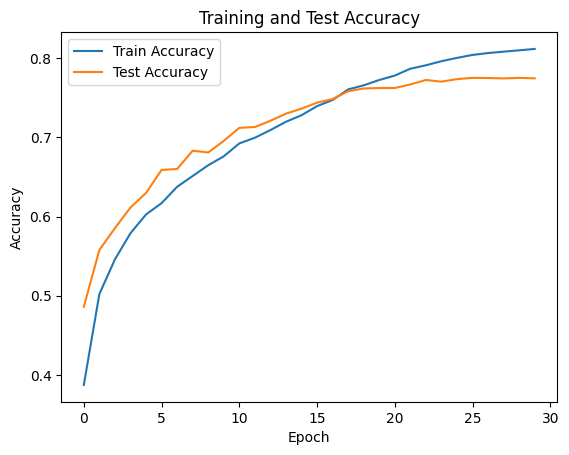

In [17]:
# Plot accuracy
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Test Accuracy')
plt.show()